In [2]:
# Import all necessary files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Import the data
df = pd.read_csv("../data/superheated_vapor.csv")
df.head()

,Pressure,Property,Liq_Sat,Vap_Sat,75,100,125,150,175,200,...,425,450,475,500,525,550,575,600,625,650
0,1.0,V,1.000,129200.0000,160640.0000,172180.0000,183720.0000,195270.0000,206810.0000,218350.0000,...,NaN,333730.00,NaN,356810.0000,NaN,379880.0000,NaN,402960.0000,NaN,426040.0000
1,1.0,U,29.334,2385.2000,2480.8000,2516.4000,2552.3000,2588.5000,2624.9000,2661.7000,...,NaN,3049.90,NaN,3132.4000,NaN,3216.7000,NaN,3302.6000,NaN,3390.3000
2,1.0,H,29.335,2514.4000,2641.5000,2688.6000,2736.0000,2783.7000,2831.7000,2880.1000,...,NaN,3383.60,NaN,3489.2000,NaN,3596.5000,NaN,3705.6000,NaN,3816.4000
3,1.0,S,0.106,8.9767,9.3828,9.5136,9.6365,9.7527,9.8629,9.9679,...,NaN,10.82,NaN,10.9612,NaN,11.0957,NaN,11.2243,NaN,11.3476
4,10.0,V,1.010,14670.0000,16030.0000,17190.0000,18350.0000,19510.0000,20660.0000,21820.0000,...,NaN,33370.00,NaN,35670.0000,NaN,37980.0000,NaN,40290.0000,NaN,42600.0000


In [5]:
df.shape

(544, 37)

In [6]:
df.columns.to_list()

['Pressure',
 'Property',
 'Liq_Sat',
 'Vap_Sat',
 '75',
 '100',
 '125',
 '150',
 '175',
 '200',
 '220',
 '225',
 '240',
 '250',
 '260',
 '275',
 '280',
 '290',
 '300',
 '320',
 '325',
 '340',
 '350',
 '360',
 '375',
 '380',
 '400',
 '425',
 '450',
 '475',
 '500',
 '525',
 '550',
 '575',
 '600',
 '625',
 '650']

Many things to notice from observing the data above:

We have 4 different properties V, U, H and S referring to the specific properties volume, internal energy, enthalpy, and entropy respectively.
We have values for each property at different pressures [kPa] and temperatures [°C].
We have also the value of each property at each pressure for the saturated liquid and vapor.
Since we plan to build models per each property individually, let’s separate the data per property.

In [7]:
# Separating the dataset into 4 datasets
V = df.loc[df['Property'] == 'V']
U = df.loc[df['Property'] == 'U']
H = df.loc[df['Property'] == 'H']
S = df.loc[df['Property'] == 'S']

In [8]:
V.head()

,Pressure,Property,Liq_Sat,Vap_Sat,75,100,125,150,175,200,...,425,450,475,500,525,550,575,600,625,650
0,1.0,V,1.000,129200.0,160640.0,172180.0,183720.0,195270.0,206810.0,218350.0,...,NaN,333730.0,NaN,356810.0,NaN,379880.0,NaN,402960.0,NaN,426040.0
4,10.0,V,1.010,14670.0,16030.0,17190.0,18350.0,19510.0,20660.0,21820.0,...,NaN,33370.0,NaN,35670.0,NaN,37980.0,NaN,40290.0,NaN,42600.0
8,20.0,V,1.017,7649.8,8000.0,8584.7,9167.1,9748.0,10320.0,10900.0,...,NaN,16680.0,NaN,17830.0,NaN,18990.0,NaN,20140.0,NaN,21300.0
12,30.0,V,1.022,5229.3,5322.0,5714.4,6104.6,6493.2,6880.8,7267.5,...,NaN,11120.0,NaN,11890.0,NaN,12660.0,NaN,13430.0,NaN,14190.0
16,40.0,V,1.027,3993.4,NaN,4279.2,4573.3,4865.8,5157.2,5447.8,...,NaN,8340.1,NaN,8917.6,NaN,9494.9,NaN,10070.0,NaN,10640.0


In [9]:
V.shape

(136, 37)

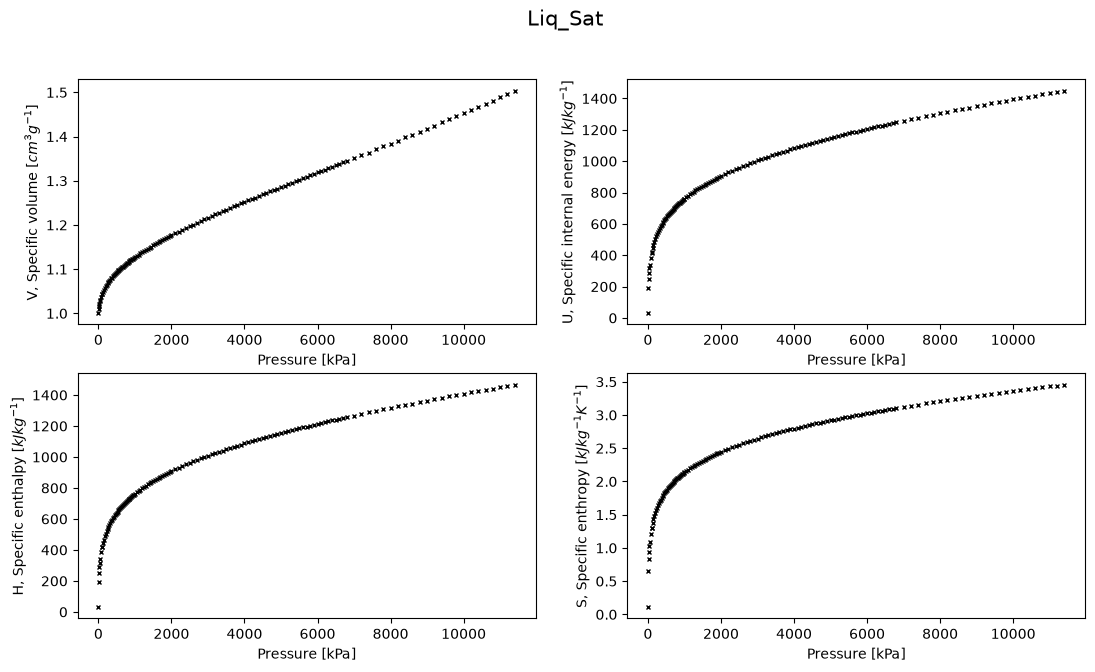

In [10]:
# Plotting the Liq_sat 
property_to_plot = 'Liq_Sat'

# Plot saturated liquid
plt.figure(figsize=(13, 7))
plt.subplot(221)
plt.plot(V['Pressure'], V[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('V, Specific volume [$cm^3 g^{-1}$]')

plt.subplot(222)
plt.plot(U['Pressure'], U[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('U, Specific internal energy [$kJ kg^{-1}$]')

plt.subplot(223)
plt.plot(H['Pressure'], H[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('H, Specific enthalpy [$kJ kg^{-1}$]')

plt.subplot(224)
plt.plot(S['Pressure'], S[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('S, Specific enthropy [$kJ kg^{-1} K^{-1}$]')

plt.suptitle(property_to_plot, size=15)
plt.show()

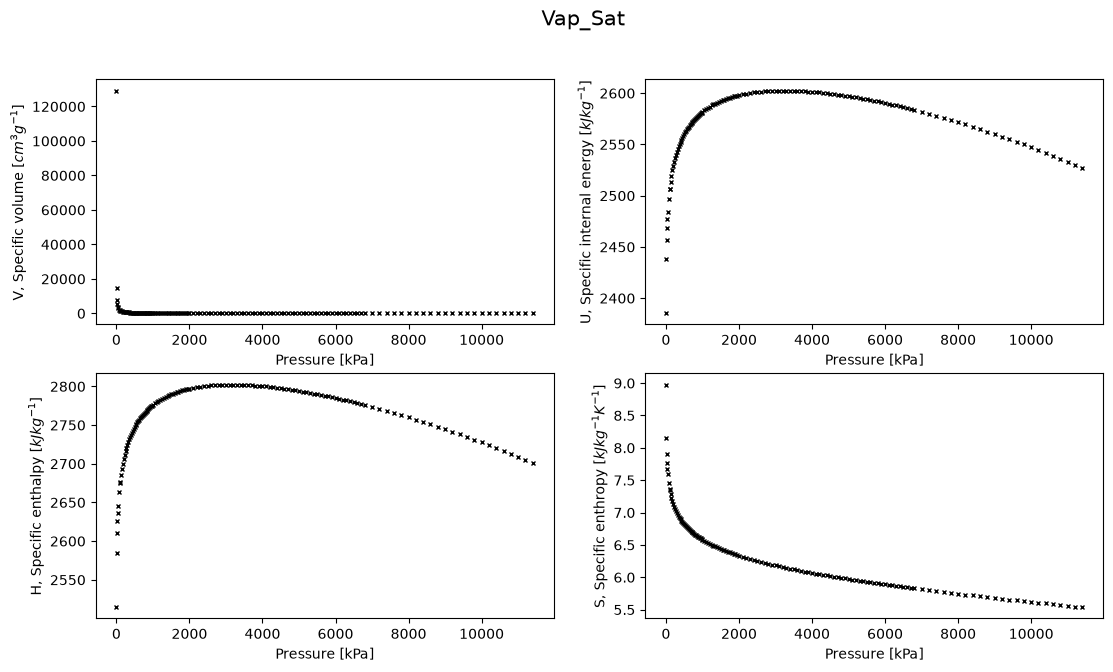

In [11]:
# Plot the Vap_Sat
property_to_plot = "Vap_Sat"

plt.figure(figsize=(13, 7))
plt.subplot(221)
plt.plot(V['Pressure'], V[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('V, Specific volume [$cm^3 g^{-1}$]')

plt.subplot(222)
plt.plot(U['Pressure'], U[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('U, Specific internal energy [$kJ kg^{-1}$]')

plt.subplot(223)
plt.plot(H['Pressure'], H[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('H, Specific enthalpy [$kJ kg^{-1}$]')

plt.subplot(224)
plt.plot(S['Pressure'], S[property_to_plot], 'kx', markersize=3)
plt.xlabel('Pressure [kPa]')
plt.ylabel('S, Specific enthropy [$kJ kg^{-1} K^{-1}$]')

plt.suptitle(property_to_plot, size=15)
plt.show()


In [16]:
# Picking v as the first property
# Fitting a Linaer regression over the entire range
# Spliiting X and y

X = V['Pressure'].values.reshape(-1, 1)
y = V['Liq_Sat'].values.reshape(-1, 1)

from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X, y)
print(f"Linear Regression model score: {model_lr.score(X, y)}")
print(f"Linear Regression model intercept: {model_lr.intercept_}")
print(f"Linear Regression model coefficient: {model_lr.coef_[0]}")

Linear Regression model score: 0.9751457240928116
Linear Regression model intercept: [1.0780201]
Linear Regression model coefficient: [3.92152714e-05]


In [14]:
y.shape

(136, 1)

In [15]:
y.max()

np.float64(129200.0)

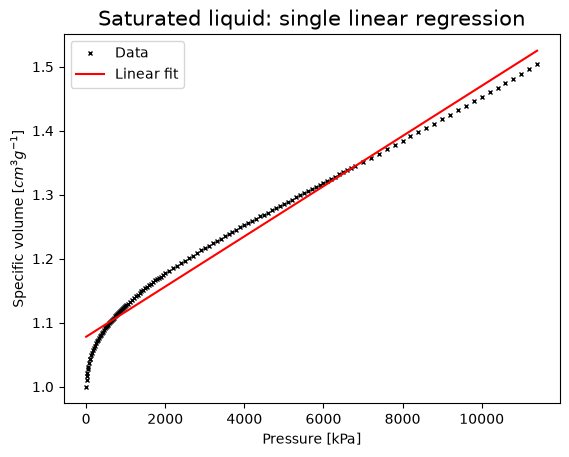

In [17]:
# Grid of pressures for drawing the fitted line
P_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

plt.figure()
plt.plot(X, y, 'kx', markersize=3, label='Data')
plt.plot(P_grid, model_lr.predict(P_grid), 'r', linewidth=1.5, label='Linear fit')
plt.xlabel('Pressure [kPa]')
plt.ylabel('Specific volume [$cm^3 g^{-1}$]')
plt.title('Saturated liquid: single linear regression', size=15)
plt.legend()
plt.show()

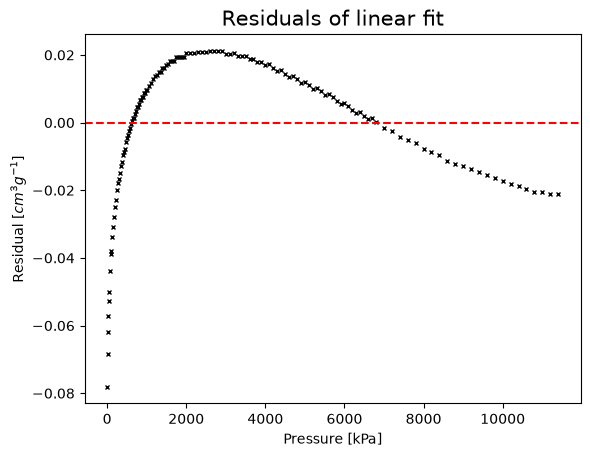

In [18]:
# Residual plot
residuals = y - model_lr.predict(X)

plt.figure()
plt.plot(X, residuals, 'kx', markersize=3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Pressure [kPa]')
plt.ylabel('Residual [$cm^3 g^{-1}$]')
plt.title('Residuals of linear fit', size=15)
plt.show()


 Residual Analysis

A residual is the actual value minus the model's prediction (y - ŷ). Plotting residuals against pressure shows where and how the model misses.

- **Positive residual:** the data point is above the line (model underestimates).
- **Negative residual:** the data point is below the line (model overestimates).
- **Good fit:** residuals scatter randomly around zero with no pattern.

Observations

- Residuals are not random. They follow a smooth curve: negative at low pressure (down to about -0.08), positive in the mid range (peak of about +0.02 near 2500 kPa), and negative again at high pressure (about -0.02).
- This systematic pattern means the model form is wrong. Saturated liquid volume is curved in P, and a straight line cannot capture that.
- The largest error is at low pressure, where the real curve rises steeply. The line overestimates there (predicts about 1.08 vs. an actual value of about 1.00).

Why R² is still high (0.975)

- R² measures the fraction of total variance explained, averaged over all points. It does not show where the errors occur or whether they have structure.
- The total variance is dominated by the long high-pressure range, where the data is nearly linear, so the line explains most of it.
- The steep low-pressure region contains few points and small absolute errors, so it barely affects R².
- Takeaway: a high R² does not mean a good model. Always check residuals. A systematic pattern signals a missing non-linear term, which motivates piecewise fits and GLMs with basis functions.

In [20]:
# As per the tutorial, we will divide into three parts and fit a linear regression to each part.
#  The three parts are defined by the following limits: less than 300 kPa, between 300 and 1500 kPa, and greater than 1500 kPa.

lim_1 = 300
lim_2 = 1500

First_P  = V['Pressure'].loc[V['Pressure'] < lim_1].to_numpy().reshape(-1, 1)
First_V  = V['Liq_Sat'].loc[V['Pressure'] < lim_1].to_numpy().reshape(-1, 1)

Second_P = V['Pressure'].loc[(V['Pressure'] >= lim_1) & 
                                  (V['Pressure'] < lim_2)].to_numpy().reshape(-1, 1)
Second_V = V['Liq_Sat'].loc[(V['Pressure'] >= lim_1) & 
                                  (V['Pressure'] < lim_2)].to_numpy().reshape(-1, 1)

Third_P  = V['Pressure'].loc[V['Pressure'] >= lim_2].to_numpy().reshape(-1, 1)
Third_V  = V['Liq_Sat'].loc[V['Pressure'] >= lim_2].to_numpy().reshape(-1, 1)


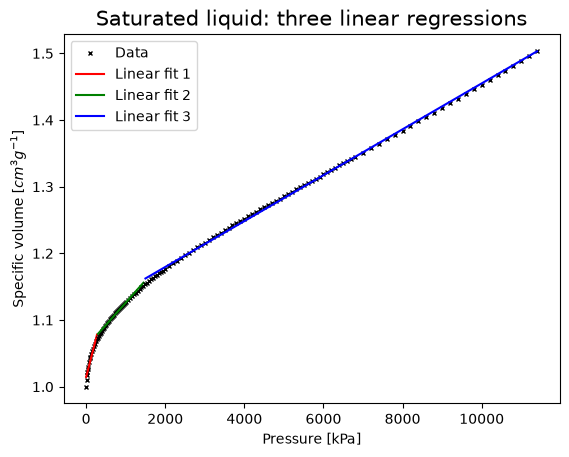

In [21]:
# Now we will fit a linear regression to each part and plot the results.
model_1 = LinearRegression().fit(First_P, First_V)
model_2 = LinearRegression().fit(Second_P, Second_V)
model_3 = LinearRegression().fit(Third_P, Third_V)

# Plotting the results
plt.figure()
plt.xlabel('Pressure [kPa]')
plt.ylabel('Specific volume [$cm^3 g^{-1}$]')

# First part
plt.plot(First_P, First_V, 'kx', markersize=3, label='Data')
plt.plot(First_P, model_1.predict(First_P), 'r', linewidth=1.5, label='Linear fit 1')

# Second part
plt.plot(Second_P, Second_V, 'kx', markersize=3)    
plt.plot(Second_P, model_2.predict(Second_P), 'g', linewidth=1.5, label='Linear fit 2')

# Third part
plt.plot(Third_P, Third_V, 'kx', markersize=3)
plt.plot(Third_P, model_3.predict(Third_P), 'b', linewidth=1.5, label='Linear fit 3')

plt.title('Saturated liquid: three linear regressions', size=15)
plt.legend()
plt.show()

In [25]:
# Print the metrics for each model
print("R2 Scores:")
print(f"Linear Regression model 1 score: {model_1.score(First_P, First_V)}")
print(f"Linear Regression model 2 score: {model_2.score(Second_P, Second_V)}")
print(f"Linear Regression model 3 score: {model_3.score(Third_P, Third_V)}")

print("Coefficients:")
print(f"Linear Regression model 1 coefficient: {model_1.coef_[0]}") 
print(f"Linear Regression model 2 coefficient: {model_2.coef_[0]}")
print(f"Linear Regression model 3 coefficient: {model_3.coef_[0]}")

print("Intercepts:")
print(f"Linear Regression model 1 intercept: {model_1.intercept_}")
print(f"Linear Regression model 2 intercept: {model_2.intercept_}")
print(f"Linear Regression model 3 intercept: {model_3.intercept_}") 

R2 Scores:
Linear Regression model 1 score: 0.9263208134364597
Linear Regression model 2 score: 0.9870087187227413
Linear Regression model 3 score: 0.9990370407798591
Coefficients:
Linear Regression model 1 coefficient: [0.00023137]
Linear Regression model 2 coefficient: [6.67710359e-05]
Linear Regression model 3 coefficient: [3.44236231e-05]
Intercepts:
Linear Regression model 1 intercept: [1.01438786]
Linear Regression model 2 intercept: [1.05921557]
Linear Regression model 3 intercept: [1.11072464]
